# **Introduction: AI Workplace Productivity**

The AI Workplace Productivity dataset explores the intersection of artificial intelligence, employee work habits, and overall productivity within a modern professional environment. It is a comprehensive collection of 4,500 employee records across various job roles (e.g., Managers, Analyst, Developer, Writer, Marketer etc...).
The goal of this project is to predict, as a regression task, the productivity_score of an employee in the workplace, ranging from 0 t 100, based on AI tool usage and work habits.

Dataset Source: https://www.kaggle.com/datasets/vishardmehta/ai-tool-usage-and-workplace-productivity-dataset?phase=FinishSSORegistration&returnUrl=%2Fdatasets%2Fvishardmehta%2Fai-tool-usage-and-workplace-productivity-dataset%2Fversions%2F1%3Fresource%3Ddownload&SSORegistrationToken=CfDJ8L9-_gcGHthJtufiBgcc1oaiRTjTRrigooSz5KsTrni1KRFXmPDZ3HrErybMo3c2QteX1PO_Yk8V6HqKZAZG2rekLSCpHb4DB0qUBfuhSm319EamAGI3Jqh1f83V9mteSIYt0BYoMCQ6nA3pk3YfYqsgC8tlqiyqKxnPR0Kj2RhliCHe9WqsWAV-ZInCLoATchWKaY3ROJ2cZrrHqXI9GJevTkiwFDu2UUTauNcs7Nt8i5ckeFBX8F2v62O6PtXR6bNiJjAzOC--xLx940WvS7sIssMlQylQvMIUU2gAtwRzhcyLrHG2QW1_QKN2zRTHYIZZJN8nrwpy-4XztsDQS0oYkNenUoSR5ot3VoTdyeOxLJ0&DisplayName=SARA+DI+FRANCO&select=ai_productivity_targets.csv

# **Data Integration and Preparation**

## Importing Modules

In [2]:
pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 88.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import itertools

## Data Loading 

Upload the feature and target Files and Merge the Data to make a unique Dataset with both feature variables and Target variables.

In [4]:
# Upload the files
features = pd.read_csv('ai_productivity_features.csv')
targets = pd.read_csv('ai_productivity_targets.csv')

# Merge the data 
dataset = pd.merge(features, targets, on='Employee_ID', how='inner')

# The final dataset 
dataset

,Employee_ID,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score,productivity_score,burnout_risk_level
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,Writer,19,11.8,28.5,19.2,1.4,High,1.9,2.3,0.20,2,7.1,4.8,10.00,81.0,High
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,Designer,4,10.8,24.1,23.3,2.6,Low,8.0,9.8,1.82,3,3.4,5.5,6.78,59.2,Medium
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,Developer,6,25.9,69.4,10.0,1.4,Medium,6.8,8.9,5.52,5,4.6,3.8,9.66,62.4,High
3,14511660-d78a-453f-9449-f17cd239ec27,Manager,20,7.9,17.2,25.1,0.2,High,3.5,8.6,1.14,5,5.6,3.9,10.00,76.8,High
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,Developer,15,8.6,20.6,20.1,1.4,Low,5.9,5.3,2.75,10,1.0,7.4,5.38,53.7,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,05acc22b-86b7-4aa4-9b80-33b3c77a5b82,Developer,18,4.9,15.2,30.3,3.3,Low,1.4,8.1,0.10,3,8.0,6.8,5.80,93.9,Medium
4496,338e2ff5-8be0-48de-8abb-98c72f5648b3,Writer,17,20.9,49.8,10.0,2.6,High,3.1,10.6,0.10,1,5.7,4.5,10.00,81.7,High
4497,249bce23-5c4b-4671-8239-1e121109a680,Manager,7,4.8,21.1,21.0,0.6,Low,7.2,6.6,3.97,6,3.6,7.8,5.08,60.6,Medium
4498,ffc95b77-3960-4b40-908f-1275ba5bbf91,Analyst,20,6.9,12.3,28.6,1.3,Medium,8.3,8.2,0.94,6,4.5,3.6,9.83,69.8,High


### Initial feature selection

To ensure the methodological soundness and generalization capability of the regression model, a rigorous feature selection strategy was applied based on the following principle:

- Removal of Non-Informative Identifiers and Bias Sources --> We dropped the Employee_ID columnas it represents a unique identifier with no intrinsic predictive value. Its inclusion would increase the risk of overfitting by allowing the model to memorize individual observations instead of learning generalizable patterns.
- Removal of Task-Irrelevant Features --> We droppped the burnout_risk_score column as it is not directly related to the prediction objective (productivity_score).
- Prevention of Data Leakage --> We also dropped burnout_risk_level column  because it is directly derived from the target burnout score which we are not interested in.

In [5]:
# Drop Employee_ID column because it doesn't add any value to the model (avoiding overfitting)
dataset = dataset.drop(columns=['Employee_ID'])
# Drop burnout_risk_level beacuse it leads to data leakage 
dataset = dataset.drop(columns=['burnout_risk_level'])
# Drop burnout_risk_score because it is not directly related to the productivity_score
dataset = dataset.drop(columns=['burnout_risk_score'])

# **Task 1:** Exploratory Data Analysis (EDA)

In [7]:
pip install matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 63.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 80.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 61.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 98.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 52.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [seaborn]1/12 [seaborn]ib]n]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

EXPLORATORY DATA ANALYSIS (EDA) - AI WORKPLACE PRODUCTIVITY


### 1. Dataset Summary and Overview

In [9]:
# Dataset Dimensions and Information
print("\n1. DATASET DIMENSIONS AND STRUCTURE")
print("-" * 80)
print(f"Shape: {dataset.shape[0]} rows, {dataset.shape[1]} columns")
print(f"\nColumn Names and Types:")
print(dataset.dtypes)
print(f"\nMissing Values:")
print(dataset.isnull().sum())
print(f"\nMemory Usage: {dataset.memory_usage().sum() / 1024:.2f} KB")



1. DATASET DIMENSIONS AND STRUCTURE
--------------------------------------------------------------------------------
Shape: 4500 rows, 14 columns

Column Names and Types:
job_role                            str
experience_years                  int64
ai_tool_usage_hours_per_week    float64
tasks_automated_percent         float64
manual_work_hours_per_week      float64
learning_time_hours_per_week    float64
deadline_pressure_level             str
meeting_hours_per_week          float64
collaboration_hours_per_week    float64
error_rate_percent              float64
task_complexity_score             int64
focus_hours_per_day             float64
work_life_balance_score         float64
productivity_score              float64
dtype: object

Missing Values:
job_role                        0
experience_years                0
ai_tool_usage_hours_per_week    0
tasks_automated_percent         0
manual_work_hours_per_week      0
learning_time_hours_per_week    0
deadline_pressure_level         0

In [10]:
# Descriptive Statistics
print("\n\n2. STATISTICAL SUMMARY")
print("-" * 80)
print("\nDescriptive Statistics for Numeric Variables:")
print(dataset.describe().round(3))

# Analysis of categorical variables
print("\n\n3. CATEGORICAL VARIABLES ANALYSIS")
print("-" * 80)
categorical_cols = dataset.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {dataset[col].nunique()}")
    print(f"  Distribution:\n{dataset[col].value_counts()}")




2. STATISTICAL SUMMARY
--------------------------------------------------------------------------------

Descriptive Statistics for Numeric Variables:
       experience_years  ai_tool_usage_hours_per_week  \
count          4500.000                      4500.000   
mean             10.428                        10.350   
std               5.745                         5.808   
min               1.000                         0.000   
25%               6.000                         6.000   
50%              10.000                         9.700   
75%              15.000                        14.300   
max              20.000                        30.400   

       tasks_automated_percent  manual_work_hours_per_week  \
count                 4500.000                    4500.000   
mean                    25.908                      22.373   
std                     15.158                       6.466   
min                      0.000                      10.000   
25%                    

### 2. Statistical Distributions Analysis

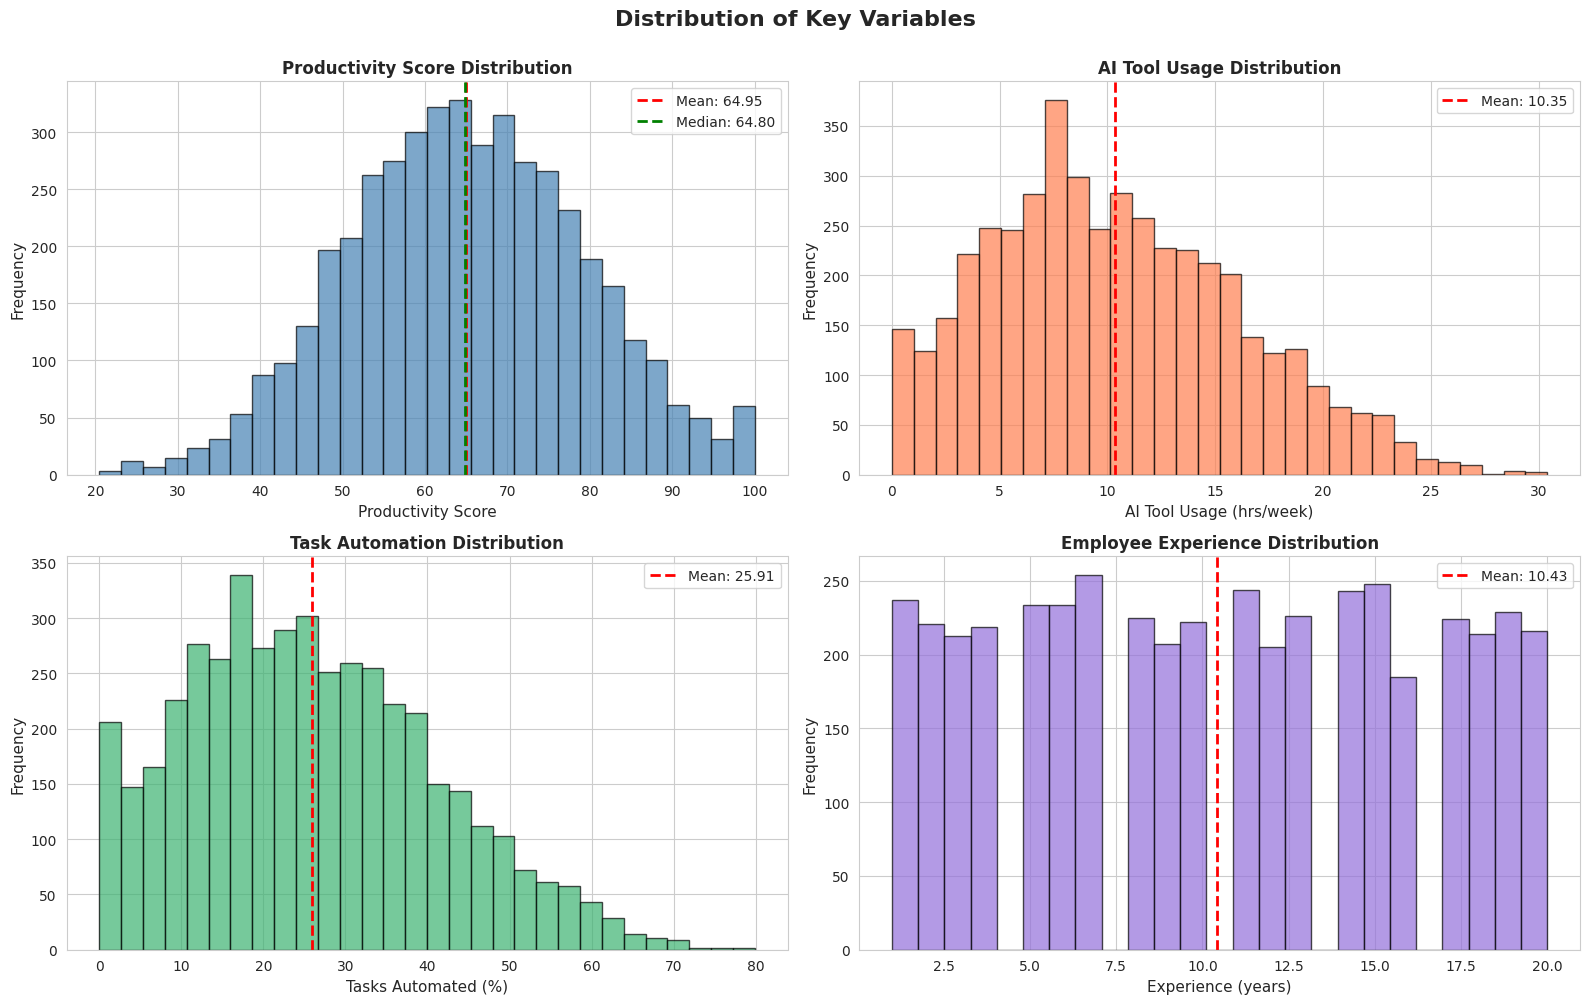


Distribution Statistics:

productivity_score:
  Skewness: 0.010 (Right-skewed)
  Kurtosis: -0.248

ai_tool_usage_hours_per_week:
  Skewness: 0.429 (Right-skewed)
  Kurtosis: -0.333

tasks_automated_percent:
  Skewness: 0.434 (Right-skewed)
  Kurtosis: -0.302

experience_years:
  Skewness: 0.016 (Right-skewed)
  Kurtosis: -1.193


In [ ]:
# Distribution of Key Variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold', y=1.00)

# Productivity Score Distribution
axes[0, 0].hist(dataset['productivity_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Productivity Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Productivity Score Distribution', fontweight='bold')
axes[0, 0].axvline(dataset['productivity_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dataset["productivity_score"].mean():.2f}')
axes[0, 0].axvline(dataset['productivity_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {dataset["productivity_score"].median():.2f}')
axes[0, 0].legend()

# AI Tool Usage Hours Distribution
axes[0, 1].hist(dataset['ai_tool_usage_hours_per_week'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('AI Tool Usage (hrs/week)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('AI Tool Usage Distribution', fontweight='bold')
axes[0, 1].axvline(dataset['ai_tool_usage_hours_per_week'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dataset["ai_tool_usage_hours_per_week"].mean():.2f}')
axes[0, 1].legend()

# Tasks Automated Percentage Distribution
axes[1, 0].hist(dataset['tasks_automated_percent'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Tasks Automated (%)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Task Automation Distribution', fontweight='bold')
axes[1, 0].axvline(dataset['tasks_automated_percent'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dataset["tasks_automated_percent"].mean():.2f}')
axes[1, 0].legend()

# Experience Years Distribution
axes[1, 1].hist(dataset['experience_years'], bins=25, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Experience (years)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Employee Experience Distribution', fontweight='bold')
axes[1, 1].axvline(dataset['experience_years'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dataset["experience_years"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


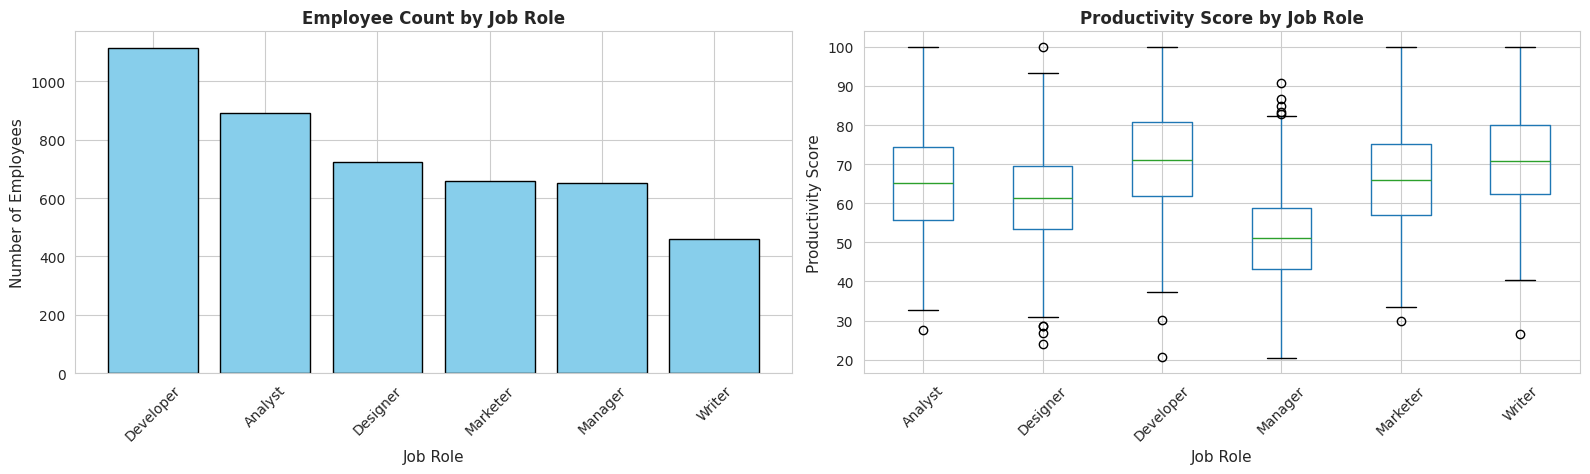

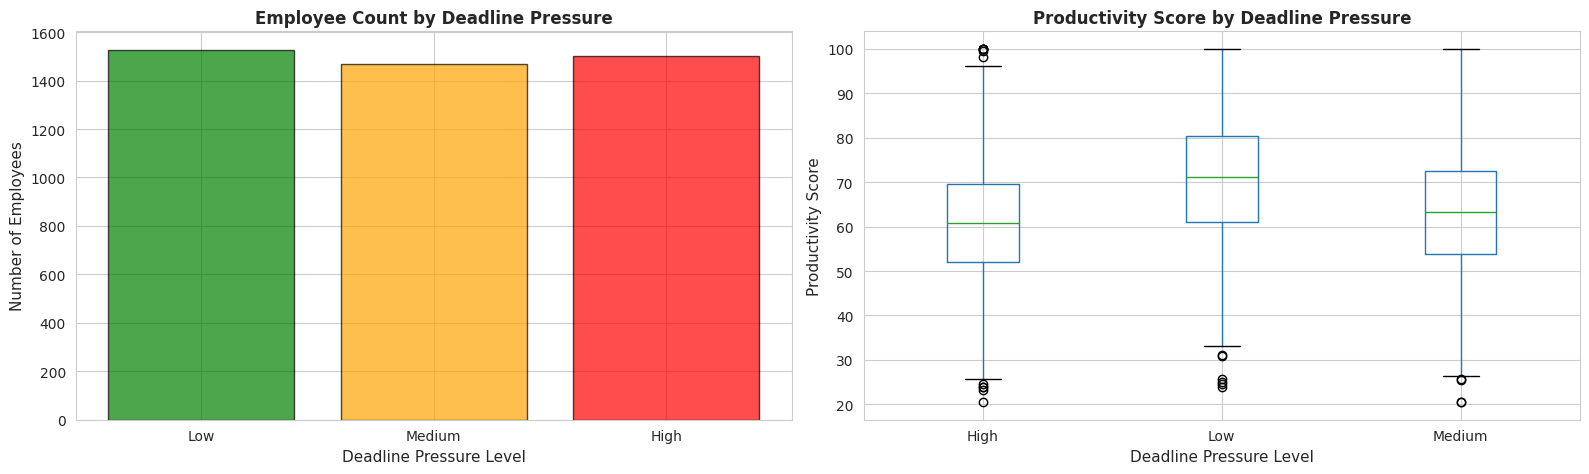


Productivity Statistics by Job Role:
            count   mean    std   min    25%    50%    75%    max
job_role                                                         
Analyst     892.0  65.52  13.04  27.5  55.70  65.25  74.40  100.0
Designer    722.0  61.50  12.04  23.9  53.30  61.25  69.57  100.0
Developer  1115.0  71.37  13.30  20.6  61.80  71.10  80.75  100.0
Manager     652.0  51.31  11.91  20.5  43.10  51.10  58.80   90.7
Marketer    658.0  66.14  12.62  29.9  57.12  66.05  75.18  100.0
Writer      461.0  71.27  12.69  26.5  62.40  70.90  79.90  100.0

Productivity Statistics by Deadline Pressure:
                          count   mean    std   min    25%    50%    75%  \
deadline_pressure_level                                                    
High                     1503.0  61.03  13.19  20.6  51.95  60.80  69.70   
Low                      1527.0  70.54  14.21  24.0  61.00  71.10  80.50   
Medium                   1470.0  63.14  13.66  20.5  53.80  63.35  72.57   

      

In [12]:
# Job Role Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Job Role Analysis', fontsize=16, fontweight='bold')

# Job Role Distribution
role_counts = dataset['job_role'].value_counts()
axes[0].bar(role_counts.index, role_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Job Role', fontsize=11)
axes[0].set_ylabel('Number of Employees', fontsize=11)
axes[0].set_title('Employee Count by Job Role', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Productivity by Job Role (Box Plot)
dataset.boxplot(column='productivity_score', by='job_role', ax=axes[1])
axes[1].set_xlabel('Job Role', fontsize=11)
axes[1].set_ylabel('Productivity Score', fontsize=11)
axes[1].set_title('Productivity Score by Job Role', fontweight='bold')
axes[1].get_figure().suptitle('')  # Remove the automatic title
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Productivity by Deadline Pressure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Deadline Pressure Impact Analysis', fontsize=16, fontweight='bold')

pressure_order = ['Low', 'Medium', 'High']
axes[0].bar(dataset['deadline_pressure_level'].value_counts()[pressure_order].index,
            dataset['deadline_pressure_level'].value_counts()[pressure_order].values,
            color=['green', 'orange', 'red'], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Deadline Pressure Level', fontsize=11)
axes[0].set_ylabel('Number of Employees', fontsize=11)
axes[0].set_title('Employee Count by Deadline Pressure', fontweight='bold')

dataset.boxplot(column='productivity_score', by='deadline_pressure_level', ax=axes[1])
axes[1].set_xlabel('Deadline Pressure Level', fontsize=11)
axes[1].set_ylabel('Productivity Score', fontsize=11)
axes[1].set_title('Productivity Score by Deadline Pressure', fontweight='bold')
axes[1].get_figure().suptitle('')
plt.tight_layout()
plt.show()

print("\nProductivity Statistics by Job Role:")
print(dataset.groupby('job_role')['productivity_score'].describe().round(2))
print("\nProductivity Statistics by Deadline Pressure:")
print(dataset.groupby('deadline_pressure_level')['productivity_score'].describe().round(2))


### 3. Correlation Analysis

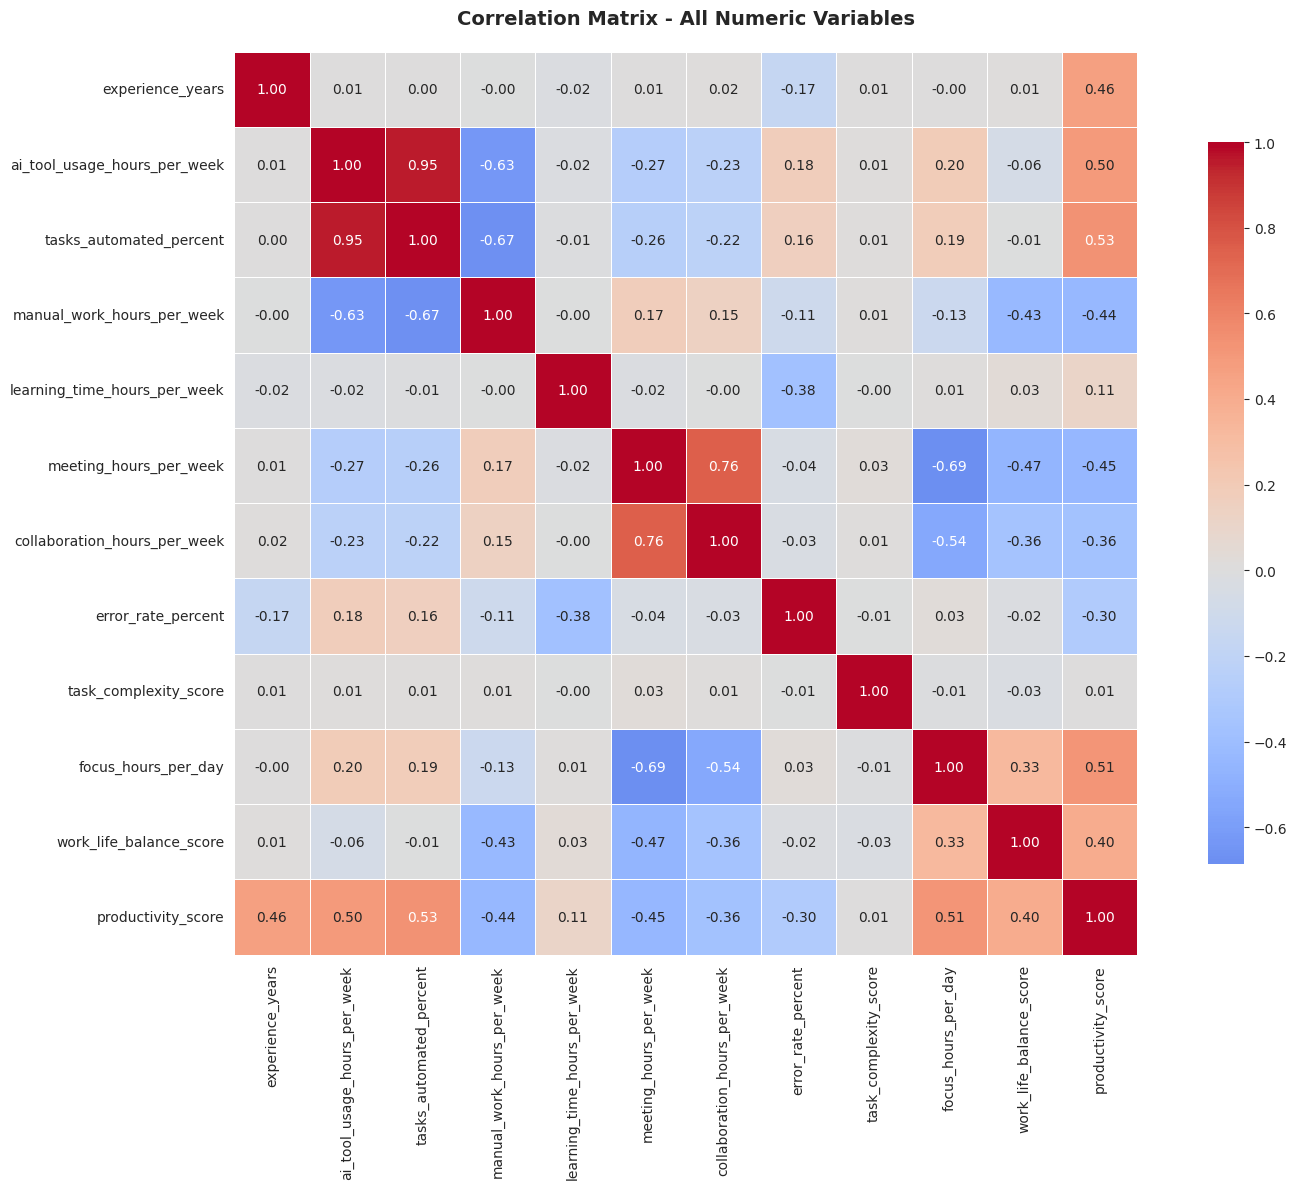



4. CORRELATION WITH PRODUCTIVITY SCORE
--------------------------------------------------------------------------------

Correlation Coefficients (sorted by strength):
productivity_score              1.000000
tasks_automated_percent         0.533995
focus_hours_per_day             0.514713
ai_tool_usage_hours_per_week    0.498452
experience_years                0.463643
work_life_balance_score         0.403521
learning_time_hours_per_week    0.112890
task_complexity_score           0.005009
error_rate_percent             -0.295577
collaboration_hours_per_week   -0.364280
manual_work_hours_per_week     -0.439878
meeting_hours_per_week         -0.445299
Name: productivity_score, dtype: float64


TOP 5 POSITIVE CORRELATIONS with Productivity Score:
tasks_automated_percent         0.533995
focus_hours_per_day             0.514713
ai_tool_usage_hours_per_week    0.498452
experience_years                0.463643
work_life_balance_score         0.403521
Name: productivity_score, dtype: floa

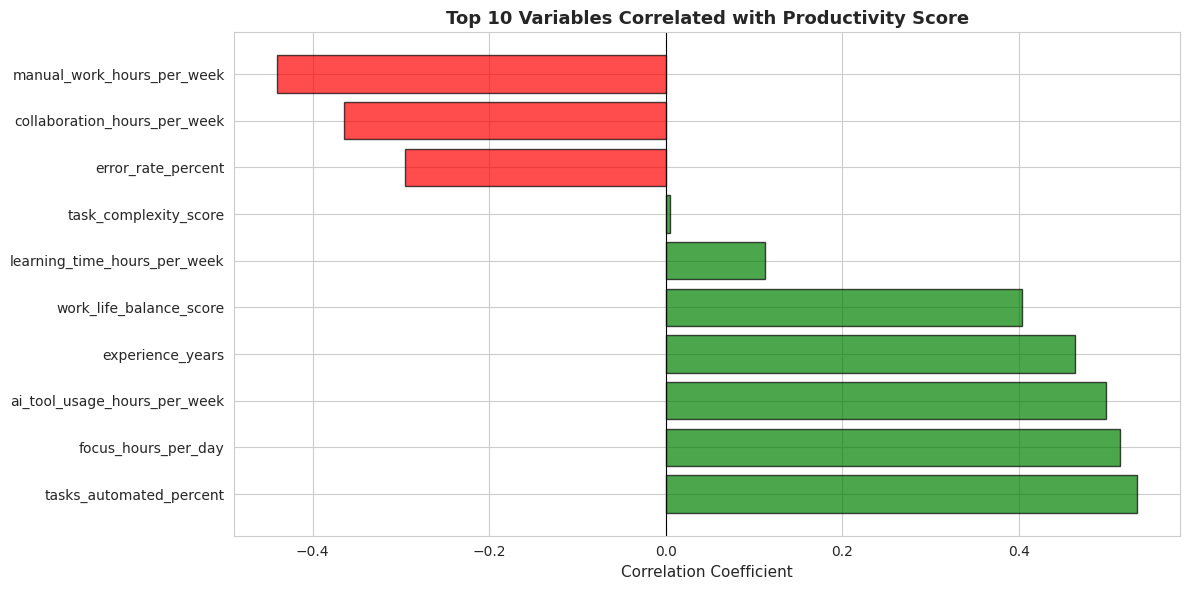

In [13]:
# Select only numeric columns for correlation
numeric_data = dataset.select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - All Numeric Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with Productivity Score
print("\n\n4. CORRELATION WITH PRODUCTIVITY SCORE")
print("-" * 80)
productivity_corr = correlation_matrix['productivity_score'].sort_values(ascending=False)
print("\nCorrelation Coefficients (sorted by strength):")
print(productivity_corr)

# Top positive and negative correlations with productivity
print("\n\nTOP 5 POSITIVE CORRELATIONS with Productivity Score:")
print(productivity_corr[1:6])  # Skip productivity_score itself

print("\n\nTOP 5 NEGATIVE CORRELATIONS with Productivity Score:")
print(productivity_corr[-5:])

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 6))
top_corr = productivity_corr[1:11]  # Top 10 (excluding itself)
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation Coefficient', fontsize=11)
ax.set_title('Top 10 Variables Correlated with Productivity Score', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()


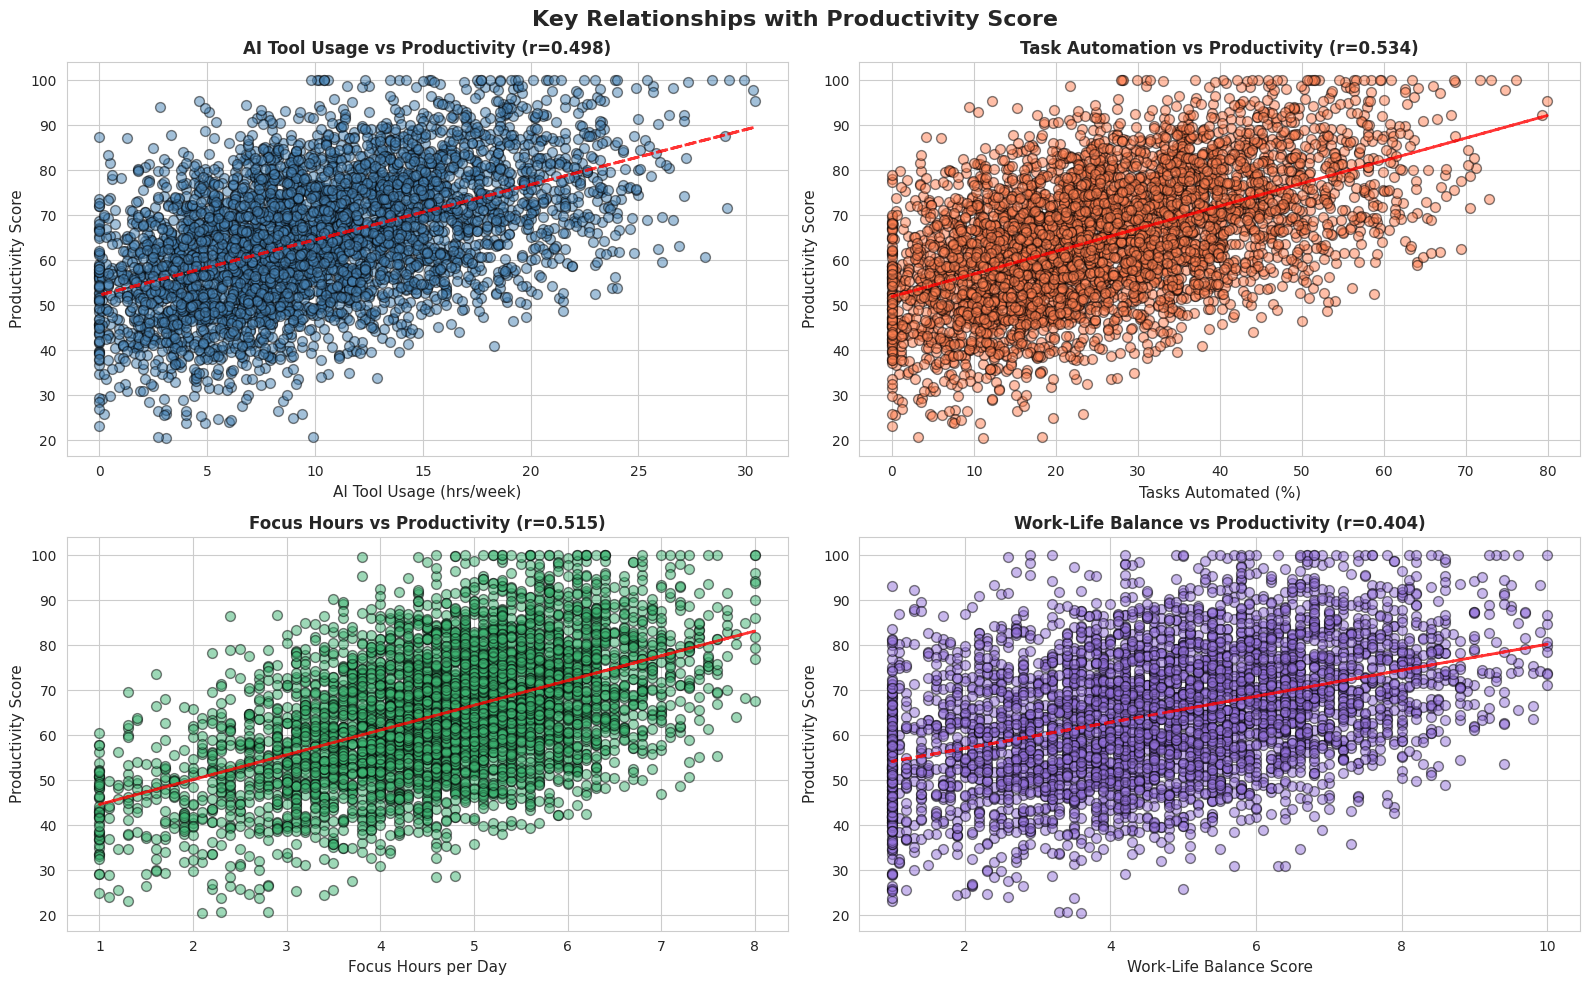

In [14]:
# Scatter plots for top correlations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Key Relationships with Productivity Score', fontsize=16, fontweight='bold')

# AI Tool Usage vs Productivity
axes[0, 0].scatter(dataset['ai_tool_usage_hours_per_week'], dataset['productivity_score'], 
                   alpha=0.5, color='steelblue', edgecolors='black', s=50)
axes[0, 0].set_xlabel('AI Tool Usage (hrs/week)', fontsize=11)
axes[0, 0].set_ylabel('Productivity Score', fontsize=11)
axes[0, 0].set_title(f'AI Tool Usage vs Productivity (r={correlation_matrix.loc["ai_tool_usage_hours_per_week", "productivity_score"]:.3f})', fontweight='bold')
z = np.polyfit(dataset['ai_tool_usage_hours_per_week'], dataset['productivity_score'], 1)
p = np.poly1d(z)
axes[0, 0].plot(dataset['ai_tool_usage_hours_per_week'], p(dataset['ai_tool_usage_hours_per_week']), "r--", alpha=0.8, linewidth=2)

# Tasks Automated vs Productivity
axes[0, 1].scatter(dataset['tasks_automated_percent'], dataset['productivity_score'], 
                   alpha=0.5, color='coral', edgecolors='black', s=50)
axes[0, 1].set_xlabel('Tasks Automated (%)', fontsize=11)
axes[0, 1].set_ylabel('Productivity Score', fontsize=11)
axes[0, 1].set_title(f'Task Automation vs Productivity (r={correlation_matrix.loc["tasks_automated_percent", "productivity_score"]:.3f})', fontweight='bold')
z = np.polyfit(dataset['tasks_automated_percent'], dataset['productivity_score'], 1)
p = np.poly1d(z)
axes[0, 1].plot(dataset['tasks_automated_percent'], p(dataset['tasks_automated_percent']), "r--", alpha=0.8, linewidth=2)

# Focus Hours vs Productivity
axes[1, 0].scatter(dataset['focus_hours_per_day'], dataset['productivity_score'], 
                   alpha=0.5, color='mediumseagreen', edgecolors='black', s=50)
axes[1, 0].set_xlabel('Focus Hours per Day', fontsize=11)
axes[1, 0].set_ylabel('Productivity Score', fontsize=11)
axes[1, 0].set_title(f'Focus Hours vs Productivity (r={correlation_matrix.loc["focus_hours_per_day", "productivity_score"]:.3f})', fontweight='bold')
z = np.polyfit(dataset['focus_hours_per_day'], dataset['productivity_score'], 1)
p = np.poly1d(z)
axes[1, 0].plot(dataset['focus_hours_per_day'], p(dataset['focus_hours_per_day']), "r--", alpha=0.8, linewidth=2)

# Work-Life Balance vs Productivity
axes[1, 1].scatter(dataset['work_life_balance_score'], dataset['productivity_score'], 
                   alpha=0.5, color='mediumpurple', edgecolors='black', s=50)
axes[1, 1].set_xlabel('Work-Life Balance Score', fontsize=11)
axes[1, 1].set_ylabel('Productivity Score', fontsize=11)
axes[1, 1].set_title(f'Work-Life Balance vs Productivity (r={correlation_matrix.loc["work_life_balance_score", "productivity_score"]:.3f})', fontweight='bold')
z = np.polyfit(dataset['work_life_balance_score'], dataset['productivity_score'], 1)
p = np.poly1d(z)
axes[1, 1].plot(dataset['work_life_balance_score'], p(dataset['work_life_balance_score']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()


### 4. Outlier Detection and Analysis



5. OUTLIER DETECTION ANALYSIS
--------------------------------------------------------------------------------

Outliers Detected by IQR Method:

productivity_score:
  Lower Bound: 25.09, Upper Bound: 104.79
  Number of Outliers: 10 (0.2%)
  Range of Outliers: 20.50 to 25.00

ai_tool_usage_hours_per_week:
  Lower Bound: -6.45, Upper Bound: 26.75
  Number of Outliers: 14 (0.3%)
  Range of Outliers: 26.90 to 30.40

tasks_automated_percent:
  Lower Bound: -17.75, Upper Bound: 68.25
  Number of Outliers: 19 (0.4%)
  Range of Outliers: 68.50 to 79.90

focus_hours_per_day:
  Lower Bound: 1.35, Upper Bound: 8.15
  Number of Outliers: 79 (1.8%)
  Range of Outliers: 1.00 to 1.30

work_life_balance_score:
  Lower Bound: -1.05, Upper Bound: 10.55
  Number of Outliers: 0 (0.0%)

manual_work_hours_per_week:
  Lower Bound: 4.55, Upper Bound: 40.15
  Number of Outliers: 9 (0.2%)
  Range of Outliers: 40.40 to 43.30


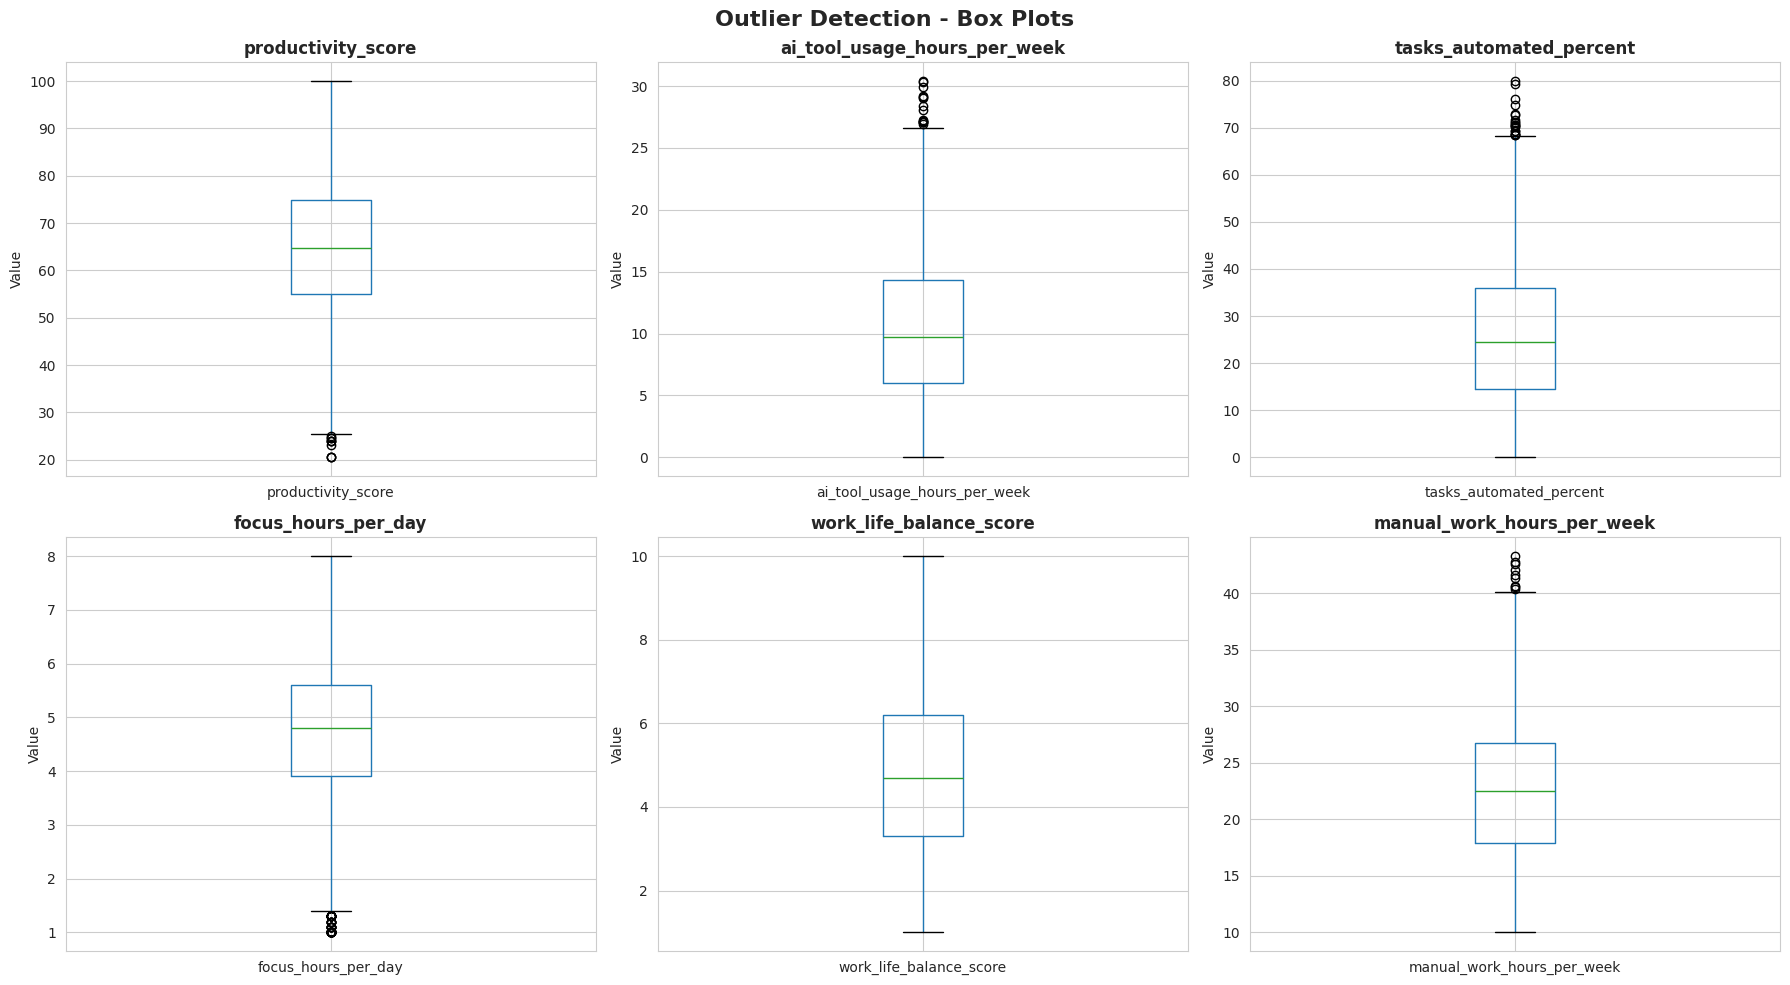



Extreme Outliers (Z-score > 3):

productivity_score: 3 extreme outliers found

ai_tool_usage_hours_per_week: 8 extreme outliers found

tasks_automated_percent: 7 extreme outliers found

manual_work_hours_per_week: 4 extreme outliers found


In [15]:
print("\n\n5. OUTLIER DETECTION ANALYSIS")
print("-" * 80)

# IQR Method for Outlier Detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Z-Score Method for Outlier Detection
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = data[z_scores > threshold]
    return outliers

# Analyze outliers for key variables
key_variables = ['productivity_score', 'ai_tool_usage_hours_per_week', 'tasks_automated_percent', 
                 'focus_hours_per_day', 'work_life_balance_score', 'manual_work_hours_per_week']

print("\nOutliers Detected by IQR Method:")
for col in key_variables:
    outliers, lower, upper = detect_outliers_iqr(dataset, col)
    print(f"\n{col}:")
    print(f"  Lower Bound: {lower:.2f}, Upper Bound: {upper:.2f}")
    print(f"  Number of Outliers: {len(outliers)} ({len(outliers)/len(dataset)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range of Outliers: {outliers[col].min():.2f} to {outliers[col].max():.2f}")

# Visualize outliers using box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(key_variables):
    dataset.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)

plt.tight_layout()
plt.show()

# Identify and display extreme outliers (Z-score > 3)
print("\n\nExtreme Outliers (Z-score > 3):")
for col in key_variables:
    extreme_outliers = detect_outliers_zscore(dataset, col, threshold=3)
    if len(extreme_outliers) > 0:
        print(f"\n{col}: {len(extreme_outliers)} extreme outliers found")


# **Task 2:** Data Visualization

# **Task 3:** Preprocessing

# **Task 4:** Modeling

# **Task 5:** Explainable AI (XAI)